<a href="https://colab.research.google.com/github/Nischay-verma/Capstone-Project-Deep-Learning-E-Commerce-Customer-Satisfaction-Score-Prediction/blob/main/Capstone_Project_Deep_Learning_E_Commerce_Customer_Satisfaction_Score_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - E-Commerce Customer Satisfaction Score Prediction



##### **Project Type**    -   Classification Artificial Neural Network (ANN)

# **Project Summary -**

This project focuses on predicting Customer Satisfaction (CSAT) scores for the Shopzilla e-commerce platform using an Artificial Neural Network (ANN). The objective was to leverage customer interaction data to build a predictive model that can accurately classify satisfaction levels and provide actionable insights for improving customer experience.

The model demonstrated strong predictive capability, helping identify patterns in customer behavior and the key factors influencing satisfaction. The insights derived from this project can support businesses in enhancing service quality, customer engagement, and overall decision-making.

####🔑 Key Steps

**Data Preparation**

Cleaned the dataset by handling missing values, removing inconsistencies, and performing feature engineering to extract meaningful variables.

**Data Transformation**

Applied feature scaling techniques to normalize the data and improve model training efficiency.

**Model Development**

Designed and trained an Artificial Neural Network (ANN) with optimized parameters.

**Model Optimization**

Implemented cross-validation to improve model robustness and reduce overfitting.

**Model Evaluation**

Assessed performance using Precision, Recall, F1-Score, and ROC-AUC Curve to ensure reliable predictions.

**Insight Generation**

Identified key drivers of customer satisfaction, enabling data-driven business decisions.

# **GitHub Link -**

https://github.com/Nischay-verma/Capstone-Project-Deep-Learning-E-Commerce-Customer-Satisfaction-Score-Prediction




# **Problem Statement**


The main objective of this project is to build a deep learning model capable of accurately predicting CSAT scores from customer interactions and feedback. This model aims to equip e-commerce businesses with a robust tool to track and improve customer satisfaction in real-time, ultimately enhancing service quality and promoting customer loyalty.

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Install required packages
!pip install tensorflow==2.17.1 keras-tuner==1.4.7 scikeras statsmodels imbalanced-learn

  Using cached ml_dtypes-0.4.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached ml_dtypes-0.4.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.2 MB)
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.4
    Uninstalling ml_dtypes-0.5.4:
      Successfully uninstalled ml_dtypes-0.5.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.17.1 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.17.1 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.17.1 which is incompatible.
jax 0.7.2 requires ml_dtypes>=0.5.0, but you have ml-dtypes 0.4.1 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but 

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Upgrade ml_dtypes to resolve JAX dependency issue
!pip install --upgrade ml_dtypes

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, roc_curve, auc, confusion_matrix
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib


# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from scikeras.wrappers import KerasClassifier

  Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.9 kB)
Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (5.0 MB)
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.17.1 requires ml-dtypes<0.5.0,>=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.17.1 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.17.1 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.17.1 which is incompatible.
jax 0.7.2 require

### Dataset Loading

In [3]:
# Load Dataset
df = pd.read_csv('eCommerce_Customer_support_data.csv')

### Dataset First View

In [4]:
# Dataset First Look
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
df.shape

(85907, 20)

### Dataset Information

In [6]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
df.duplicated().sum()

0

#### Missing Values/Null Values

In [8]:

# Missing Values/Null Values Count
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


In [9]:
# Visualizing the missing values
df.isnull().sum().sort_values(ascending = False)

,0
connected_handling_time,85665
Customer_City,68828
Product_category,68711
Item_price,68701
order_date_time,68693
Customer Remarks,57165
Order_id,18232
Agent Shift,0
Tenure Bucket,0
Manager,0


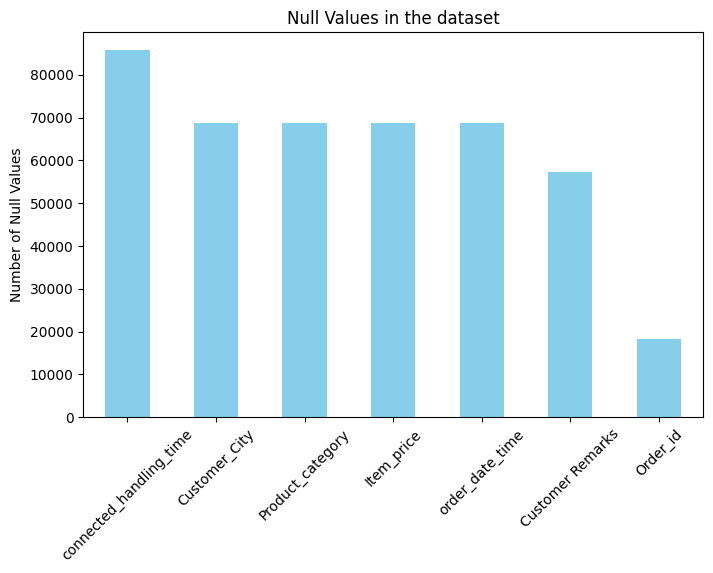

In [10]:
null_counts = df.isnull().sum().sort_values(ascending = False).head(7)
plt.figure(figsize=(8, 5))
null_counts.plot(kind='bar', color='skyblue')
plt.title('Null Values in the dataset')
plt.ylabel('Number of Null Values')
plt.xticks(rotation=45)
plt.show()

### What did you know about your dataset?

The dataset used for this project contains 85,907 records and 20 features, representing customer interaction details from the Shopzilla e-commerce platform. No duplicate entries were found in the dataset, which ensured the reliability and consistency of the data for analysis and model development.

However, missing values were identified in several columns, including Customer Remarks, Order_id, Order_date_time, Customer_city, Product_category, Item_price, and Connected_handling_time. These missing values were carefully addressed during the preprocessing stage using appropriate data cleaning techniques to maintain data quality.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [12]:
# Dataset Describe
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
df.nunique()


,0
Unique id,85907
channel_name,3
category,12
Sub-category,57
Customer Remarks,18231
Order_id,67675
order_date_time,13766
Issue_reported at,30923
issue_responded,30262
Survey_response_Date,31


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Distribution of Issue


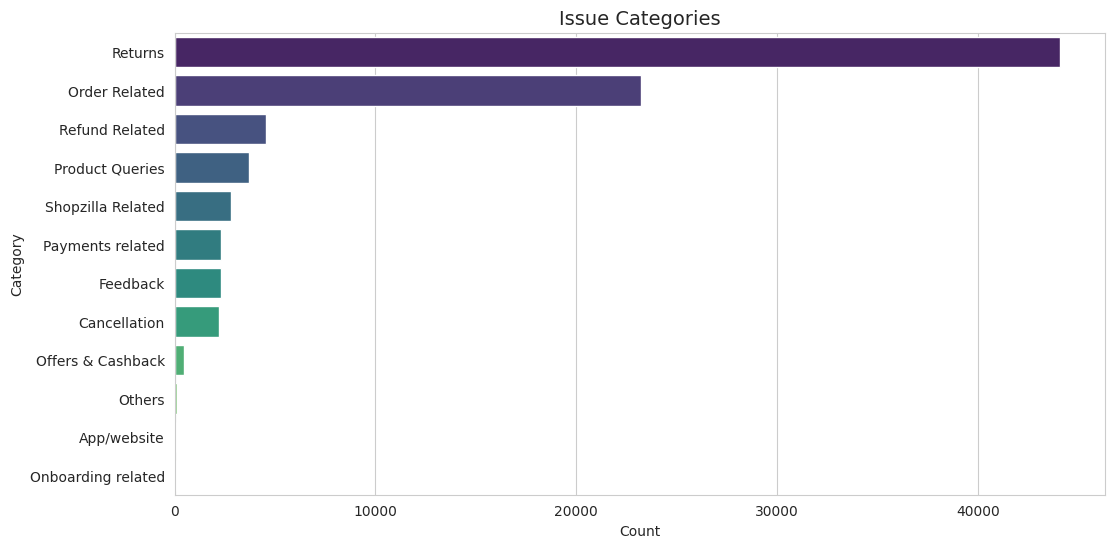

In [14]:
# Set style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))
sns.countplot(y=df["category"], order=df["category"].value_counts().index, palette="viridis")
plt.title("Issue Categories", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()


What is/are the insight(s) found from the chart?

 **Insight from the Chart:**  

*   Returns is the most frequent issue category, indicating it is the primary
driver of customer dissatisfaction and support requests.
*   Order-related issues are the second highest, suggesting challenges in order processing, tracking, or delivery.



*   Refund-related and product queries appear at moderate levels, showing customers often seek clarity on refunds and product details.

*   Payment, cancellation, feedback, and Shopzilla-related issues occur less frequently but still contribute to overall service workload.
*  Offers & cashback, app/website, onboarding, and others have very low occurrence, indicating these areas generate fewer customer complaints.
















#### Chart - 2 Distribution of CSAT


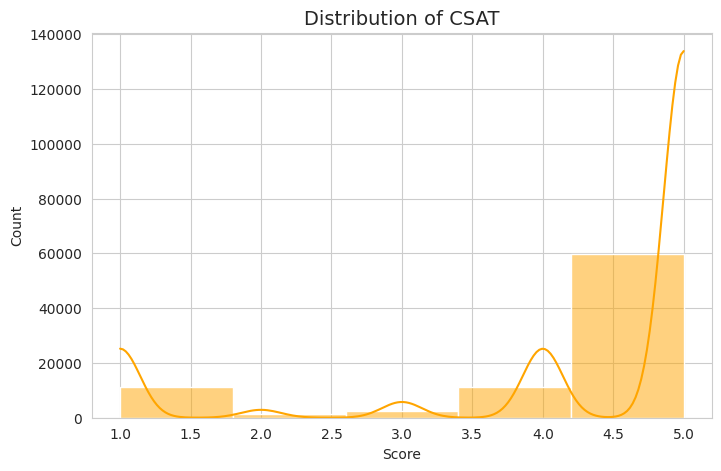

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df["CSAT Score"], bins=5, kde=True, color="Orange")
plt.title("Distribution of CSAT", fontsize=14)
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()


What is/are the insight(s) found from the chart?

* Most CSAT scores are clustered around 5.0, indicating that a large number of customers reported high satisfaction levels.

* A smaller but noticeable portion of scores falls between 1.0–1.5, reflecting poor customer experiences in certain cases.

* Mid-range scores (2.0–3.5) are comparatively fewer, suggesting customers generally reported either very positive or very negative feedback, rather than neutral opinions.

* The multiple peaks in the distribution indicate variation in customer sentiment, likely influenced by different types of customer issues or service experiences.

#### Chart - 3 Issues by Support Channel


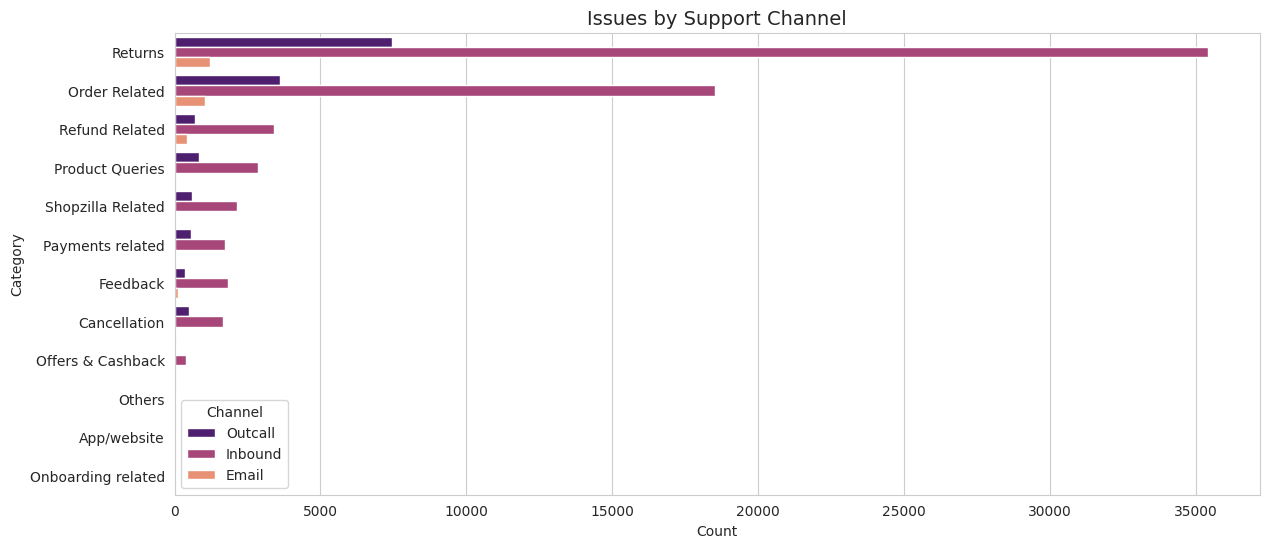

In [16]:
plt.figure(figsize=(14, 6))
sns.countplot(y=df["category"], hue=df["channel_name"], order=df["category"].value_counts().index, palette="magma")
plt.title("Issues by Support Channel", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Category")
plt.legend(title="Channel")
plt.show()

2. What is/are the insight(s) found from the chart?

* Returns and order-related issues account for the largest share of customer support interactions, with most handled through inbound channels.

* Refund and product queries also represent a significant portion of requests and are primarily managed via inbound and email support.

* Outcall support interactions are very limited across categories, indicating fewer proactive outreach efforts from the support team.

* Offers & cashback and app/website issues show very low interaction volumes, suggesting they are less frequent customer concerns compared to other issue types.

#### Chart - 4 CSAT Scores by Agent Shift


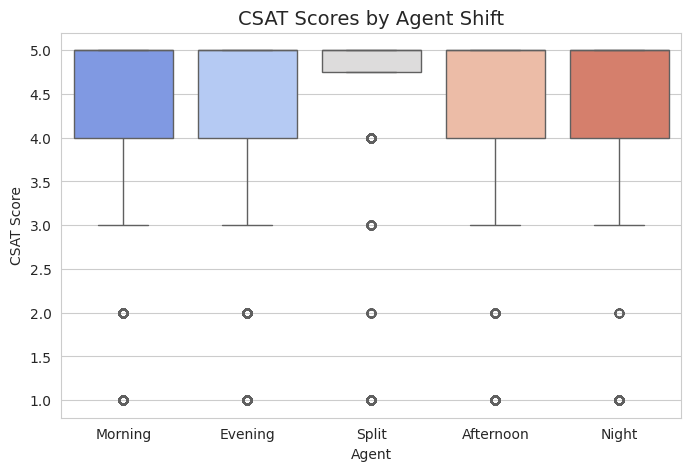

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Agent Shift"], y=df["CSAT Score"], palette="coolwarm")
plt.title("CSAT Scores by Agent Shift", fontsize=14)
plt.xlabel("Agent")
plt.ylabel("CSAT Score")
plt.show()

2. What is/are the insight(s) found from the chart?

* CSAT scores remain consistently high across all agent shifts, with most ratings concentrated between 4 and 5, indicating strong customer satisfaction.

* A small number of low ratings (1–2) appear across each shift, showing occasional dissatisfaction but not a major trend.

* The night shift also maintains high CSAT scores, suggesting service quality remains stable throughout the day.

* Overall, low variability across shifts indicates that customer satisfaction is not significantly affected by agent shift timing.

#### Chart - 5 CSAT Scores by Agent Tenure

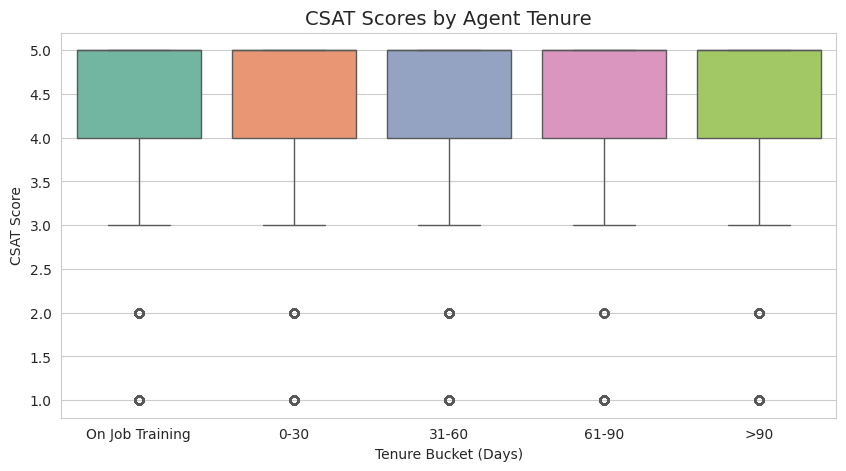

In [18]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Tenure Bucket"], y=df["CSAT Score"], order=["On Job Training", "0-30", "31-60", "61-90", ">90"], palette="Set2")
plt.title("CSAT Scores by Agent Tenure", fontsize=14)
plt.xlabel("Tenure Bucket (Days)")
plt.ylabel("CSAT Score")
plt.show()

##### 2. What is/are the insight(s) found from the chart?

1. **CSAT scores remain high across all tenure buckets**, with most ratings around 4-5.  
2. **On-the-job trainees perform similarly to experienced agents**, indicating effective training.  
3. **Low scores (1-2) are present in all tenure groups**, suggesting occasional dissatisfaction is not tenure-dependent.  
4. **Minimal variability across tenure buckets**, meaning agent experience has little impact on CSAT scores.

#### Chart - 6 Top 10 Agents Handling the Most Issues


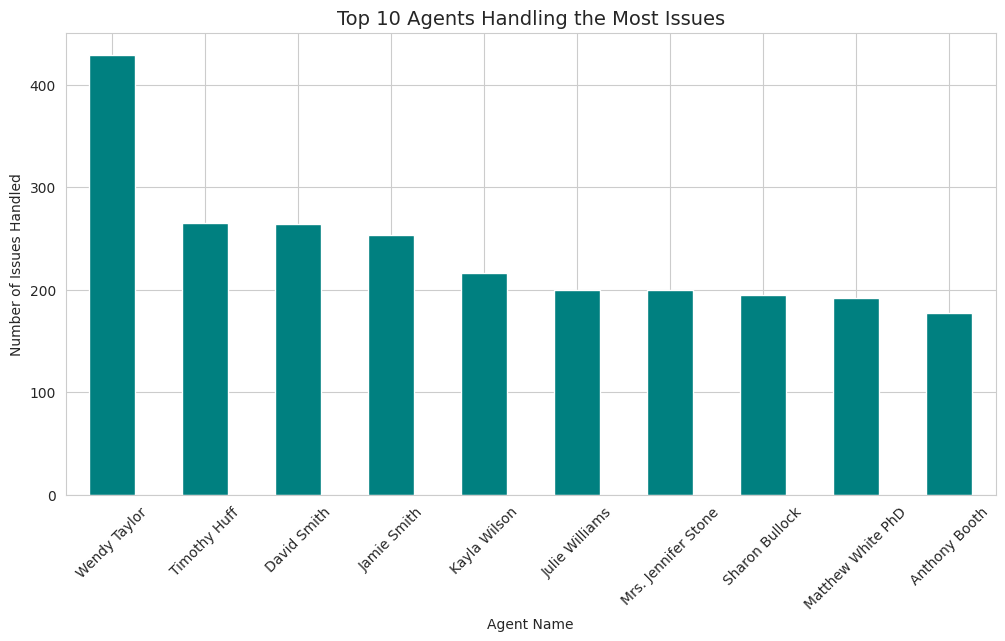

In [19]:
plt.figure(figsize=(12, 6))
df["Agent_name"].value_counts().head(10).plot(kind="bar", color="teal")
plt.title("Top 10 Agents Handling the Most Issues", fontsize=14)
plt.xlabel("Agent Name")
plt.ylabel("Number of Issues Handled")
plt.xticks(rotation=45)
plt.show()

##### 2. What is/are the insight(s) found from the chart?

1. **Wendy Taylor handles the most issues**, significantly more than others.  
2. **The next top agents handle around 200 issues**, showing a big gap from Wendy.  
3. **The last five agents have similar issue counts**, around 140-150.  
4. **Workload distribution is uneven**, with one agent handling nearly double the cases of others.

###Chart - 7 - Correlation Heatmap

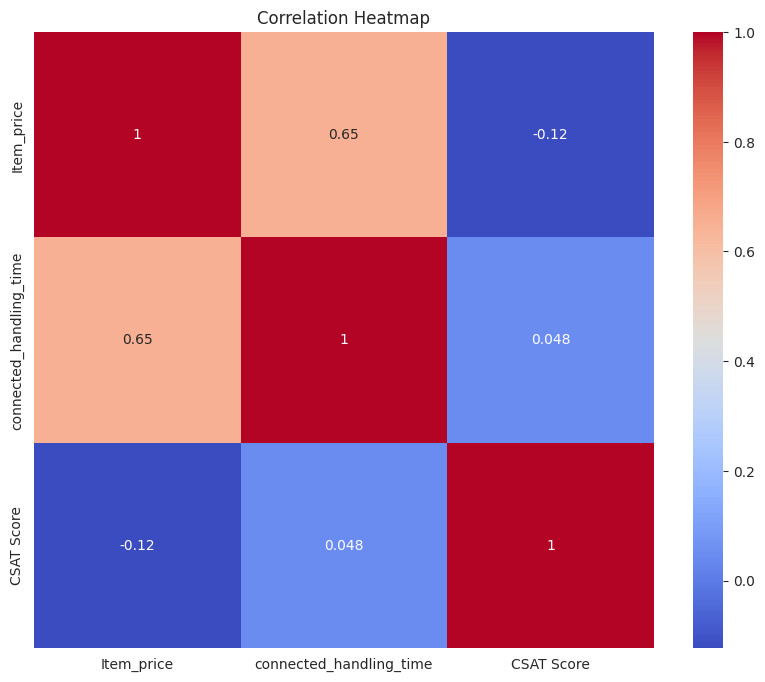

In [20]:

# Select only numeric columns for correlation calculation
numeric_data = df.select_dtypes(include=['number'])

correlation_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

1. **Item price and handling time have a moderate positive correlation (0.67)**—higher-priced items take longer to handle.  
2. **CSAT Score has a weak negative correlation (-0.12) with item price**, meaning expensive items slightly reduce satisfaction.  
3. **CSAT Score and handling time have a near-zero correlation (0.071)**, showing handling time doesn't strongly impact satisfaction.

##  **Feature Engineering & Data Pre-processing**

In [21]:
# Creating a copy of the dataset for further feature engineering
df_new=df.copy()

### 1. Handling Missing Values

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64


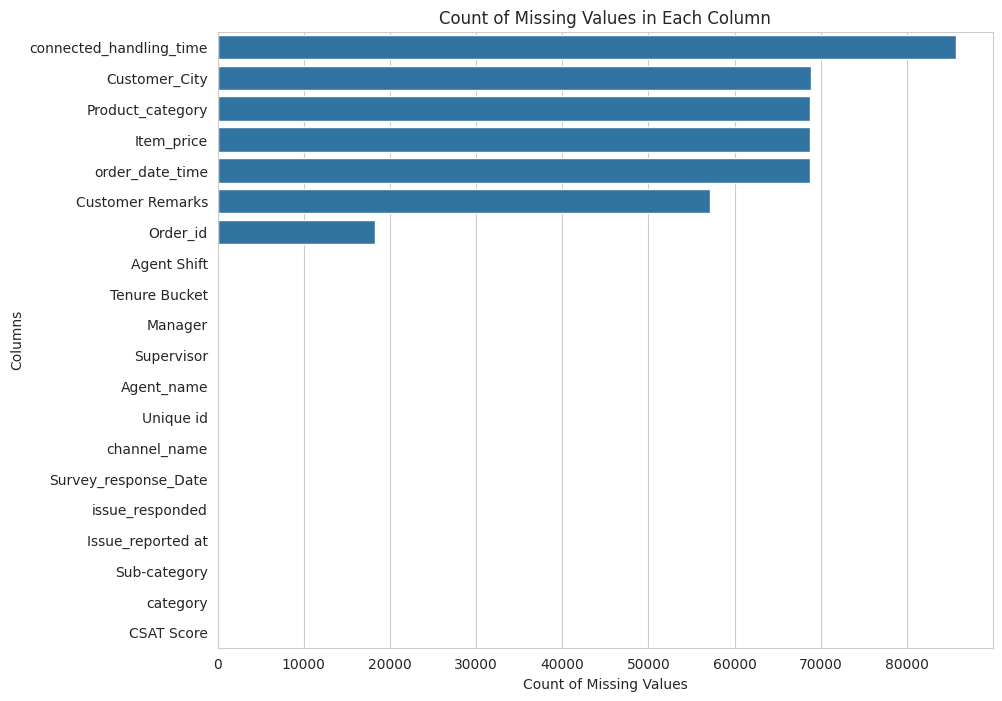

In [22]:
# Handling Missing Values & Missing Value Imputation
# Missing Values/Null Values Count
print(df_new.isnull().sum())

# Visualizing the missing values

# Step 1: Calculate the count of missing values in each column and sort in descending order
missing_values = df_new.isnull().sum().sort_values(ascending=False)


# Step 2: Create a horizontal bar plot
plt.figure(figsize=(10, 8))
sns.barplot(x=missing_values, y=missing_values.index, orient='h')
plt.xlabel('Count of Missing Values')
plt.ylabel('Columns')
plt.title('Count of Missing Values in Each Column')
plt.show()

What all missing value imputation techniques have you used and why did you use those techniques?
We employed various missing value imputation techniques based on the nature of the features and the distribution of the data:

**Order_id**: As this feature is not significant for our analysis and the number of missing values is minimal, we opted to drop this column entirely.

**Customer Remarks**: With a substantial number of missing values (57165), we couldn't discard this feature as it holds crucial information. Instead, we replaced the NaN values with "Missing Reviews" to ensure we retain the textual data for analysis.

**Categorical Column Imputation (Customer city and Product Category)**: Since these categorical features are vital for our analysis, we used mode imputation to fill in the missing values. Mode imputation was chosen as it replaces missing values with the most frequently occurring category, thereby preserving the distribution of the data.

**Numerical Column Imputation (connected_handling_time and item_price)**: For connected_handling_time, which follows a normal distribution with minimal outliers, we applied mean imputation to replace missing values. Conversely, for item_price, where outliers are more prominent, median imputation was utilized to ensure robustness against outliers.

**order_date_time**: Mode imputation was applied to handle missing values in this feature, as it represents datetime data. Subsequently, we converted it into datetime format to extract additional temporal features like day and month.

These techniques were selected to effectively manage missing data while preserving the integrity and utility of the dataset for subsequent analysis.

In [23]:
# Step 1: Drop 'Order_id' column
df_new.drop(columns=['Order_id'], inplace=True)

# Step 2: Replace missing values in 'Customer Remarks' with 'Missing Reviews'
df_new['Customer Remarks'].fillna('Missing Reviews', inplace=True)

# Step 3: Impute missing values in categorical columns ('Customer city' and 'Product Category') with mode
df_new['Customer_City'].fillna(df_new['Customer_City'].mode()[0], inplace=True)
df_new['Product_category'].fillna(df_new['Product_category'].mode()[0], inplace=True)

# Step 4: Impute missing values in numerical columns ('connected_handling_time' and 'item_price')
# Impute 'connected_handling_time' with mean
df_new['connected_handling_time'].fillna(df_new['connected_handling_time'].mean(), inplace=True)
# Impute 'item_price' with median
df_new['Item_price'].fillna(df_new['Item_price'].median(), inplace=True)

# Step 5: Impute missing values in 'order_date_time' with mode
df_new['order_date_time'].fillna(df_new['order_date_time'].mode()[0], inplace=True)


# Display the first few rows of the DataFrame to verify changes
print(df_new.head())

                              Unique id channel_name         category  \
0  7e9ae164-6a8b-4521-a2d4-58f7c9fff13f      Outcall  Product Queries   
1  b07ec1b0-f376-43b6-86df-ec03da3b2e16      Outcall  Product Queries   
2  200814dd-27c7-4149-ba2b-bd3af3092880      Inbound    Order Related   
3  eb0d3e53-c1ca-42d3-8486-e42c8d622135      Inbound          Returns   
4  ba903143-1e54-406c-b969-46c52f92e5df      Inbound     Cancellation   

                   Sub-category Customer Remarks   order_date_time  \
0                Life Insurance  Missing Reviews  09/08/2023 11:55   
1  Product Specific Information  Missing Reviews  09/08/2023 11:55   
2             Installation/demo  Missing Reviews  09/08/2023 11:55   
3        Reverse Pickup Enquiry  Missing Reviews  09/08/2023 11:55   
4                    Not Needed  Missing Reviews  09/08/2023 11:55   

  Issue_reported at   issue_responded Survey_response_Date Customer_City  \
0  01/08/2023 11:13  01/08/2023 11:47            01-Aug-23     H

In [24]:
# Missing Values/Null Values Count
print(df_new.isnull().sum())

Unique id                  0
channel_name               0
category                   0
Sub-category               0
Customer Remarks           0
order_date_time            0
Issue_reported at          0
issue_responded            0
Survey_response_Date       0
Customer_City              0
Product_category           0
Item_price                 0
connected_handling_time    0
Agent_name                 0
Supervisor                 0
Manager                    0
Tenure Bucket              0
Agent Shift                0
CSAT Score                 0
dtype: int64


### 2. Handling Outliers


In [25]:
# Handling Outliers & Outlier treatments
# To separate the symmetric distributed features and skew symmetric distributed features
df_new["CSAT Score"]=df_new["CSAT Score"].astype('str')
symmetric_feature=[]
non_symmetric_feature=[]
for i in df_new.describe().columns:
  if abs(df_new[i].mean()-df_new[i].median())<0.2:
    symmetric_feature.append(i)
  else:
    non_symmetric_feature.append(i)

# Getting Symmetric Distributed Features
print("Symmetric Distributed Features : -",symmetric_feature)

# Getting Skew Symmetric Distributed Features
print("Skew Symmetric Distributed Features : -",non_symmetric_feature)

Symmetric Distributed Features : - ['connected_handling_time']
Skew Symmetric Distributed Features : - ['Item_price']


In [26]:
# For Skew Symmetric features defining upper and lower boundry
def outlier_treatment(df,feature):
  upper_boundary= df[feature].mean()+3*df[feature].std()
  lower_boundary= df[feature].mean()-3*df[feature].std()
  return upper_boundary,lower_boundary

In [27]:
# Restricting the data to lower and upper boundry
for feature in non_symmetric_feature:
  df_new.loc[df_new[feature]<= outlier_treatment(df=df_new,feature=feature)[1], feature]=outlier_treatment(df=df_new,feature=feature)[1]
  df_new.loc[df_new[feature]>= outlier_treatment(df=df_new,feature=feature)[0], feature]=outlier_treatment(df=df_new,feature=feature)[0]

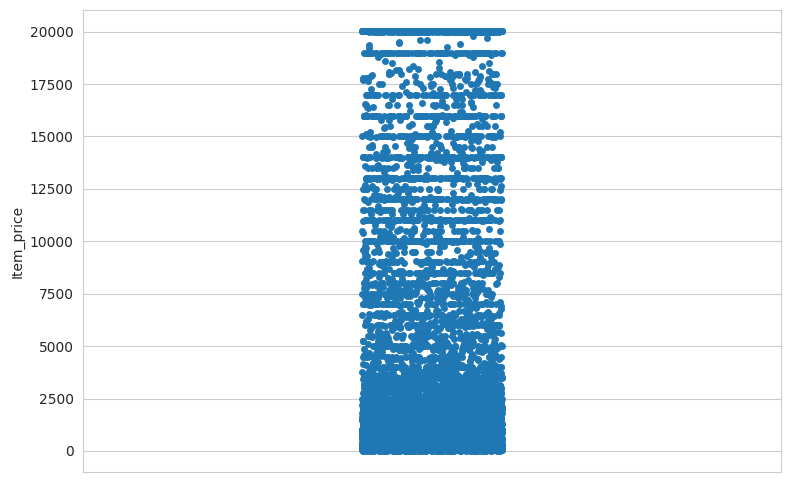

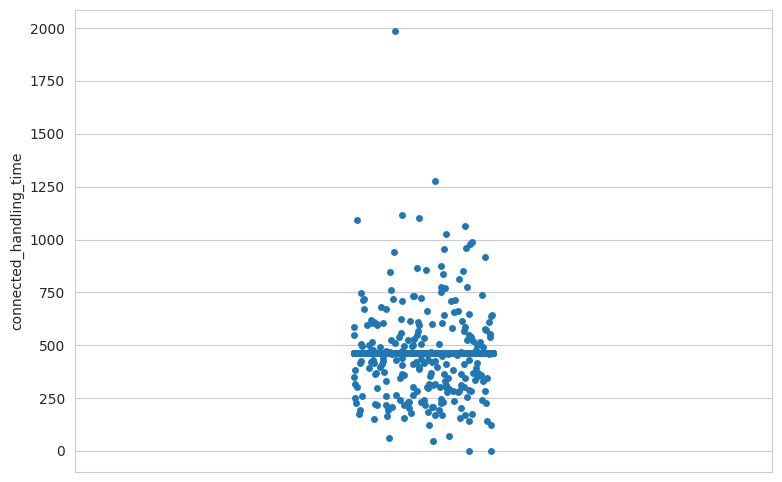

In [28]:
# After Outlier Treatment showing the dataset distribution using strip plot
# Visualising  code for the numerical columns
for col in df_new.describe().columns:
  fig=plt.figure(figsize=(9,6))
  sns.stripplot(df_new[col])

####What all outlier treatment techniques have you used and why did you use those techniques?


First I changed the CSAT Score column to sring as it shouldn't be treated as numerical column as there are only five type of values and should be treated as categorical column. Then I separated the skew symmetric and symmetric features and define the upper and lower boundry as defined below. Again, as it is a classification problem I restrict the both boundaries and I pull down the higher value restricted to the upper limit

In a Gaussian distribution while it’s the symmetric curve and outlier are present. Then, we can set the boundary by taking standard deviation into action.

### 3. Categorical Encoding


In [29]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         85907 non-null  object 
 5   order_date_time          85907 non-null  object 
 6   Issue_reported at        85907 non-null  object 
 7   issue_responded          85907 non-null  object 
 8   Survey_response_Date     85907 non-null  object 
 9   Customer_City            85907 non-null  object 
 10  Product_category         85907 non-null  object 
 11  Item_price               85907 non-null  float64
 12  connected_handling_time  85907 non-null  float64
 13  Agent_name               85907 non-null  object 
 14  Supervisor            

In [30]:
# Removing Unique id column that do not contribute to target variable
df_new.drop(columns='Unique id', inplace=True)


In [31]:
# Encode your categorical columns
# Convert "CSAT Score" to integer safely
df_new["CSAT Score"] = pd.to_numeric(df_new["CSAT Score"], errors="coerce").fillna(0).astype(int)

# Identify categorical columns
categorical_columns = list(set(df_new.columns.to_list()).difference(set(df_new.describe().columns.to_list())))

# Define non-categorical columns that should be excluded
non_cat_columns = ['issue_responded', 'order_date_time', 'Issue_reported at', 'Survey_response_Date', 'Customer Remarks']

# Remove non-categorical columns from the list
categorical_columns = list(set(categorical_columns) - set(non_cat_columns))

# Print categorical columns
print("Categorical Columns are :-", categorical_columns, " :- ", len(categorical_columns))


Categorical Columns are :- ['Agent_name', 'Supervisor', 'Product_category', 'channel_name', 'Tenure Bucket', 'Sub-category', 'Agent Shift', 'category', 'Manager', 'Customer_City']  :-  10


In [32]:
# Perform one-hot encoding
df_encoded = pd.get_dummies(df_new, columns=categorical_columns)

# Display the encoded DataFrame
df_encoded.head()

,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Item_price,connected_handling_time,CSAT Score,Agent_name_Aaron Edwards,Agent_name_Aaron Romero,...,Customer_City_YEDITHA,Customer_City_YELESWARAM,Customer_City_YEOTAMAL,Customer_City_YERRAGUNTLA,Customer_City_Yeola,Customer_City_ZAHEERABAD,Customer_City_ZAMANIA,Customer_City_ZIRA,Customer_City_ZIRAKPUR,Customer_City_ZUARINAGAR
0,Missing Reviews,09/08/2023 11:55,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,979.0,462.400826,5,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Missing Reviews,09/08/2023 11:55,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,979.0,462.400826,5,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Missing Reviews,09/08/2023 11:55,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,979.0,462.400826,5,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Missing Reviews,09/08/2023 11:55,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,979.0,462.400826,5,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Missing Reviews,09/08/2023 11:55,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,979.0,462.400826,5,False,False,...,False,False,False,False,False,False,False,False,False,False


###What all categorical encoding techniques have you used & why did you use those techniques?

I have used One Hot Encoding for all the categorical features,because these features are likely nominal categorical variables, meaning there is no inherent order or ranking among the categories. For these variables, it would be appropriate to apply one-hot encoding.

## 4. Feature Manipulation & Selection


#### 1. Feature Manipulation


In [33]:
df_encoded = df_encoded.drop(columns=["Customer Remarks"])
# remove columns Customer remarks that do not contribute to target varialbe

In [34]:
# Manipulate Features to minimize feature correlation and create new features
# Ensure the 'Issue reported at' and 'Issue responded' columns are in datetime format
df_encoded['Issue_reported at'] = pd.to_datetime(df_encoded['Issue_reported at'], format='%d/%m/%Y %H:%M')
df_encoded['issue_responded'] = pd.to_datetime(df_encoded['issue_responded'], format='%d/%m/%Y %H:%M')


# Create a new feature the response time
df_encoded['Response_Time'] = df_encoded['issue_responded'] - df_encoded['Issue_reported at']

# Convert 'Response_Time' to a numerical format in seconds for aggregation
df_encoded['Response_Time_seconds'] = df_encoded['Response_Time'].dt.total_seconds()

In [35]:
# Convert order_date_time to datetime
df_encoded['order_date_time'] = pd.to_datetime(df_encoded['order_date_time'], format='%d/%m/%Y %H:%M')

# Extract day number (day of the month)
df_encoded['day_number_order_date'] = df_encoded['order_date_time'].dt.day

# Extract weekday (numerical value: 0 for Sunday, 1 for Monday, etc.)
df_encoded['weekday_num_order_date'] = df_encoded['order_date_time'].dt.weekday + 1  # Monday=1, Sunday=7


# Convert 'Survey_response_Date' to datetime format
df_encoded['Survey_response_Date'] = pd.to_datetime(df_encoded['Survey_response_Date'], format='%d-%b-%y')

# Extract day number (day of the month)
df_encoded['day_number_response_date'] = df_encoded['Survey_response_Date'].dt.day

# Extract weekday (numerical value: 0 for Sunday, 1 for Monday, etc.)
df_encoded['weekday_num_response_date'] = df_encoded['Survey_response_Date'].dt.weekday + 1

In [36]:
# Drop Date columns after feature extraction
df_encoded.drop(columns=['order_date_time', 'Survey_response_Date','Issue_reported at','issue_responded','Response_Time'], inplace=True)

In [37]:
df_encoded.head()


,Item_price,connected_handling_time,CSAT Score,Agent_name_Aaron Edwards,Agent_name_Aaron Romero,Agent_name_Abigail Gonzalez,Agent_name_Adam Barnett,Agent_name_Adam Hammond,Agent_name_Adam Henderson,Agent_name_Adam Hernandez,...,Customer_City_ZAHEERABAD,Customer_City_ZAMANIA,Customer_City_ZIRA,Customer_City_ZIRAKPUR,Customer_City_ZUARINAGAR,Response_Time_seconds,day_number_order_date,weekday_num_order_date,day_number_response_date,weekday_num_response_date
0,979.0,462.400826,5,False,False,False,False,False,False,False,...,False,False,False,False,False,2040.0,9,3,1,2
1,979.0,462.400826,5,False,False,False,False,False,False,False,...,False,False,False,False,False,120.0,9,3,1,2
2,979.0,462.400826,5,False,False,False,False,False,False,False,...,False,False,False,False,False,1320.0,9,3,1,2
3,979.0,462.400826,5,False,False,False,False,False,False,False,...,False,False,False,False,False,1200.0,9,3,1,2
4,979.0,462.400826,5,False,False,False,False,False,False,False,...,False,False,False,False,False,120.0,9,3,1,2


Created Some new features like Response_Time_seconds,day_number_order_date,weekday_number_order_date,weekday_num_response_date and day_num_response_date

###2. Feature Selection



In [38]:
df_encoded.shape


(85907, 3298)

In [39]:
# Dropping Constant and Quasi Constant Feature
def dropping_constant(data):
    from sklearn.feature_selection import VarianceThreshold

    # Drop non-numeric columns
    numeric_data = data.select_dtypes(include=['number'])

    var_thres = VarianceThreshold(threshold=0.05)
    var_thres.fit(numeric_data)

    concol = [column for column in numeric_data.columns
              if column not in numeric_data.columns[var_thres.get_support()]]

    if "CSAT Score" in concol:
        concol.remove("CSAT Score")

    df_removed_var = data.drop(concol, axis=1)
    return df_removed_var

In [40]:
# Calling the function
df_removed_var=dropping_constant(df_encoded)

In [41]:
# Checking the shape after feature dropped
df_removed_var.shape

(85907, 3298)

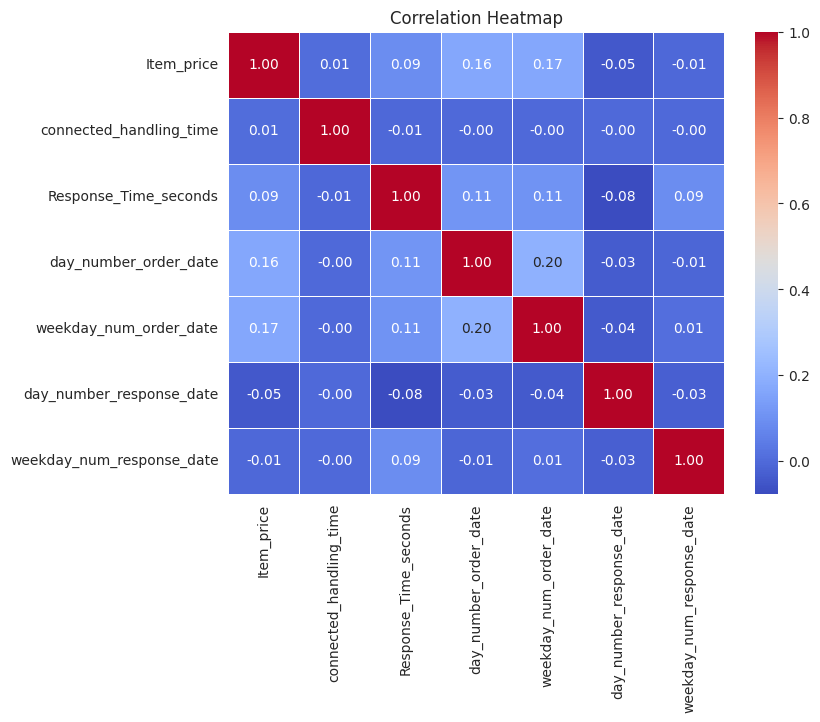

In [42]:
# Correlation Heatmap visualization code
# Drop non-numeric columns
numeric_data = df_removed_var.select_dtypes(include=['number'])
numeric_data.drop(columns=['CSAT Score'], inplace=True)
corr = numeric_data.corr()
cmap = cmap=sns.diverging_palette(5, 250, as_cmap=True)



# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [43]:
# Finding The VIF scores to know which columns are highly correlated

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = numeric_data.columns
    vif_data["VIF"] = [variance_inflation_factor(numeric_data.values, i) for i in range(numeric_data.shape[1])]
    return vif_data

# Assuming df is your DataFrame containing the features
vif_results = calculate_vif(df)
print(vif_results)

                     Feature        VIF
0                 Item_price   1.329280
1    connected_handling_time  22.090568
2      Response_Time_seconds   1.093413
3      day_number_order_date   6.462011
4     weekday_num_order_date  12.258805
5   day_number_response_date   4.487835
6  weekday_num_response_date   4.913423


In [44]:
# Drop highly correlated feature
df_removed_var.drop(columns=['weekday_num_order_date'], inplace=True)

In [45]:
# Check Feature Correlation and finding multicolinearity
def correlation(df,threshold):
  col_corr=set()
  corr_matrix= df.corr()
  for i in range (len(corr_matrix.columns)):
    for j in range(i):
      if abs (corr_matrix.iloc[i,j])>threshold:
        colname=corr_matrix.columns[i]
        col_corr.add(colname)
  return list(col_corr)

In [46]:
# Getting multicolinear columns and dropping them
numeric_data = df_removed_var.select_dtypes(include=['number'])
numeric_data.drop(columns=['CSAT Score'], inplace=True)
highly_correlated_columns=correlation(numeric_data,0.5)

if "CSAT Score" in highly_correlated_columns:
  highly_correlated_columns.remove("CSAT Score")
else:
  pass

df_removed=df_removed_var.drop(highly_correlated_columns,axis=1)
df_removed.shape

(85907, 3297)

In [47]:
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = numeric_data.columns
    vif_data["VIF"] = [variance_inflation_factor(numeric_data.values, i) for i in range(numeric_data.shape[1])]
    return vif_data

# Assuming df is your DataFrame containing the features
vif_results = calculate_vif(df)
print(vif_results)

                     Feature        VIF
0                 Item_price   1.306889
1    connected_handling_time  13.904575
2      Response_Time_seconds   1.087071
3      day_number_order_date   6.261296
4   day_number_response_date   4.486682
5  weekday_num_response_date   4.913003


In [48]:
# After Feature Selection checking the shape left with
df_removed.shape

(85907, 3297)

In [49]:
df_removed.isnull().sum()

,0
Item_price,0
connected_handling_time,0
CSAT Score,0
Agent_name_Aaron Edwards,0
Agent_name_Aaron Romero,0
...,...
Customer_City_ZUARINAGAR,0
Response_Time_seconds,0
day_number_order_date,0
day_number_response_date,0


I used **Variance Inflation Factor (VIF)** to detect and eliminate multicollinearity in my dataset, ensuring that independent variables were not highly correlated with each other. **VIF measures how much the variance of a regression coefficient is inflated due to multicollinearity**, with higher values indicating stronger correlation among predictors. To improve model stability and interpretability, I dropped columns with high VIF scores, retaining only those with minimal redundancy while preserving meaningful insights.

###5. Data Transformation


In [50]:
# Getting symmetric and skew symmetric features from the cplumns
symmetric_feature=[]
non_symmetric_feature=[]
for i in df_removed.describe().columns:
  if abs(df_removed[i].mean()-df_removed[i].median())<0.25:
    symmetric_feature.append(i)
  else:
    non_symmetric_feature.append(i)

# Getting Symmetric Distributed Features
print("Symmetric Distributed Features : -",symmetric_feature)
# Removing Customer Service Calls column from the list as it's an important factor
# which can't be treated as outliers here will is already leading to higher churn as we have seen furing analysis.
non_symmetric_feature.remove('CSAT Score')

# Getting Skew Symmetric Distributed Features
print("Skew Symmetric Distributed Features : -",non_symmetric_feature)

Symmetric Distributed Features : - ['connected_handling_time', 'weekday_num_response_date']
Skew Symmetric Distributed Features : - ['Item_price', 'Response_Time_seconds', 'day_number_order_date', 'day_number_response_date']


From the features, I got to know that there are 2 features which aren't symmetric so aren't following gaussian distribution and rest are having szymmetric curve. Thus, for those two columns I have used Exponential transformation to achieve gaussian distribution.

I tried with other transformations and found exponetial tranformation with no infinity value and working fine. So, I am continuing with Exponentia transformation with a power of 0.25.

#### First Transformation



In [51]:
# Transform Your data
# Exponential Transforming the required column
df_removed['Item_price']=np.sqrt(df_removed['Item_price'])
df_removed['Response_Time_seconds']=np.sqrt(df_removed['Response_Time_seconds'])
df_removed['day_number_order_date']=(df_removed['day_number_order_date'])**0.25
df_removed['day_number_response_date']=(df_removed['day_number_response_date'])**0.25

In [52]:
df_removed.isnull().sum()

,0
Item_price,0
connected_handling_time,0
CSAT Score,0
Agent_name_Aaron Edwards,0
Agent_name_Aaron Romero,0
...,...
Customer_City_ZUARINAGAR,0
Response_Time_seconds,3128
day_number_order_date,0
day_number_response_date,0


In [53]:
#Fill NaN values with the median of Response_Time_seconds columns
df_removed['Response_Time_seconds'] = df_removed['Response_Time_seconds'].fillna(df_removed['Response_Time_seconds'].median())

In [54]:
# Getting symmetric and skew symmetric features from the cplumns
symmetric_feature=[]
non_symmetric_feature=[]
for i in df_removed.describe().columns:
  if abs(df_removed[i].mean()-df_removed[i].median())<0.25:
    symmetric_feature.append(i)
  else:
    non_symmetric_feature.append(i)

# Getting Symmetric Distributed Features
print("Symmetric Distributed Features : -",symmetric_feature)
# Removing Customer Service Calls column from the list as it's an important factor
# which can't be treated as outliers here will is already leading to higher churn as we have seen furing analysis.
non_symmetric_feature.remove('CSAT Score')

# Getting Skew Symmetric Distributed Features
print("Skew Symmetric Distributed Features : -",non_symmetric_feature)

Symmetric Distributed Features : - ['connected_handling_time', 'day_number_order_date', 'day_number_response_date', 'weekday_num_response_date']
Skew Symmetric Distributed Features : - ['Item_price', 'Response_Time_seconds']


### Second Transformation



In [55]:
df_removed['Response_Time_seconds'] = np.sqrt(df_removed['Response_Time_seconds'])
df_removed['Item_price'] = (df_removed['Item_price'])**0.25

In [56]:
# Getting symmetric and skew symmetric features from the cplumns
symmetric_feature=[]
non_symmetric_feature=[]
for i in df_removed.describe().columns:
  if abs(df_removed[i].mean()-df_removed[i].median())<0.25:
    symmetric_feature.append(i)
  else:
    non_symmetric_feature.append(i)

# Getting Symmetric Distributed Features
print("Symmetric Distributed Features : -",symmetric_feature)
# Removing Customer Service Calls column from the list as it's an important factor
# which can't be treated as outliers here will is already leading to higher churn as we have seen furing analysis.
non_symmetric_feature.remove('CSAT Score')

# Getting Skew Symmetric Distributed Features
print("Skew Symmetric Distributed Features : -",non_symmetric_feature)

Symmetric Distributed Features : - ['Item_price', 'connected_handling_time', 'day_number_order_date', 'day_number_response_date', 'weekday_num_response_date']
Skew Symmetric Distributed Features : - ['Response_Time_seconds']


#### Third Transformation



In [57]:
# Perform sqrt transform on 'Response_Time_seconds' column
df_removed['Response_Time_seconds'] = np.sqrt(df_removed['Response_Time_seconds'])

In [58]:
# Getting symmetric and skew symmetric features from the cplumns
symmetric_feature=[]
non_symmetric_feature=[]
for i in df_removed.describe().columns:
  if abs(df_removed[i].mean()-df_removed[i].median())<0.25:
    symmetric_feature.append(i)
  else:
    non_symmetric_feature.append(i)

# Getting Symmetric Distributed Features
print("Symmetric Distributed Features : -",symmetric_feature)
# Removing Customer Service Calls column from the list as it's an important factor
# which can't be treated as outliers here will is already leading to higher churn as we have seen furing analysis.
non_symmetric_feature.remove('CSAT Score')

# Getting Skew Symmetric Distributed Features
print("Skew Symmetric Distributed Features : -",non_symmetric_feature)

Symmetric Distributed Features : - ['Item_price', 'connected_handling_time', 'Response_Time_seconds', 'day_number_order_date', 'day_number_response_date', 'weekday_num_response_date']
Skew Symmetric Distributed Features : - []


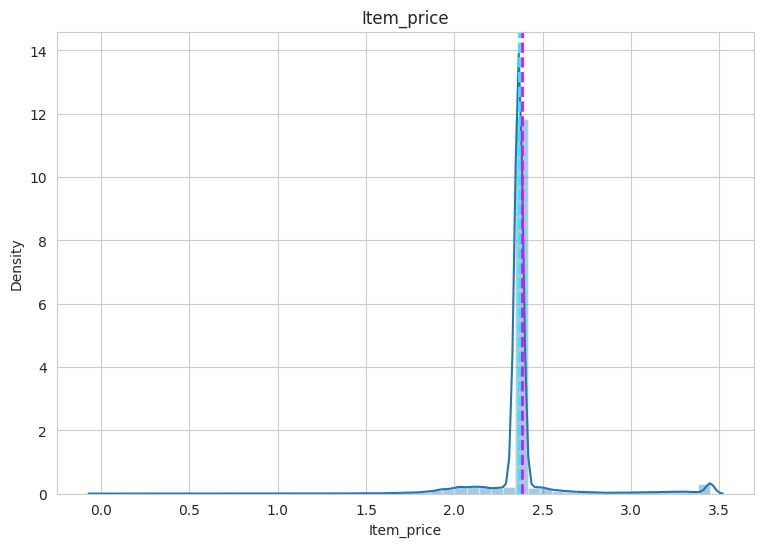

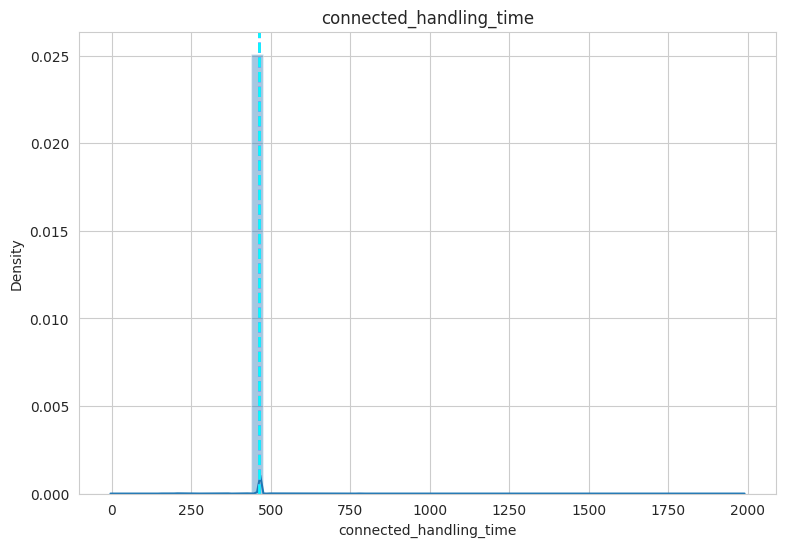

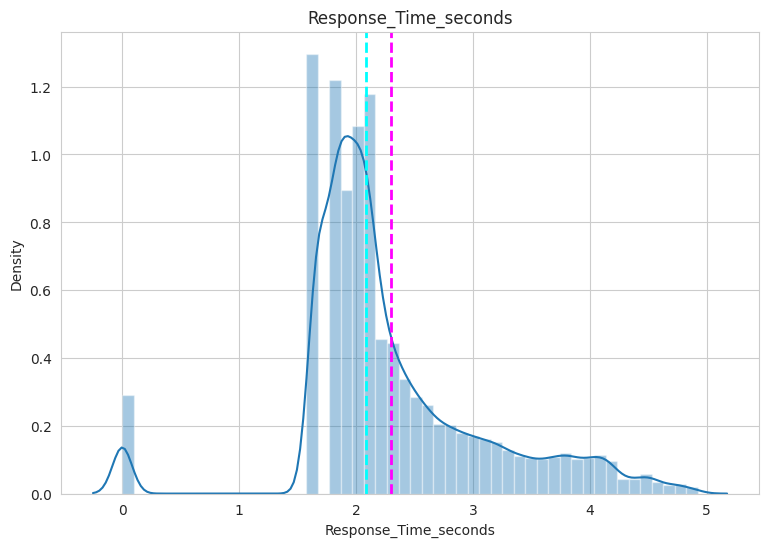

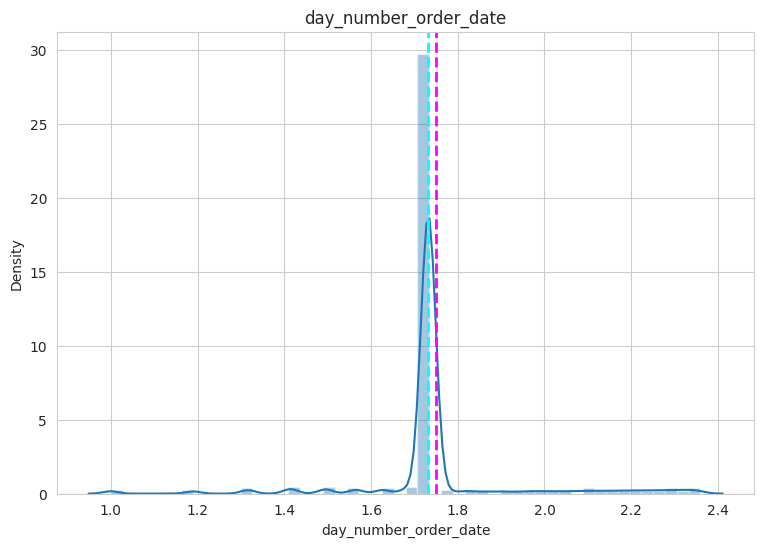

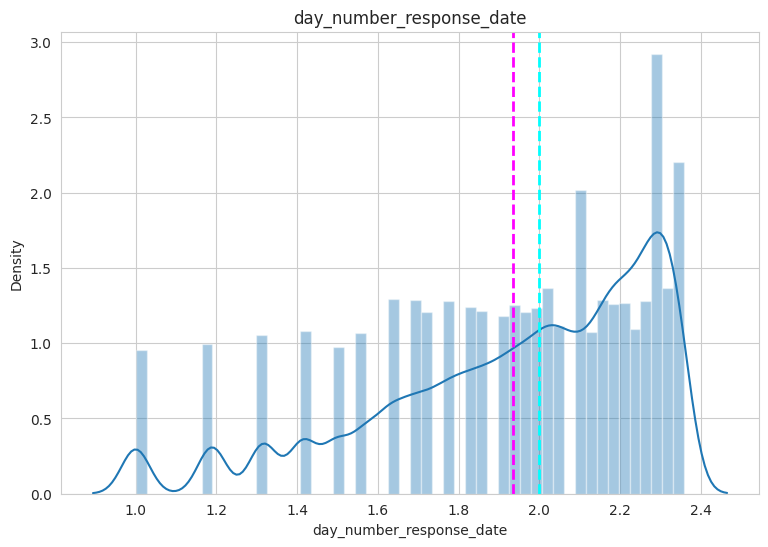

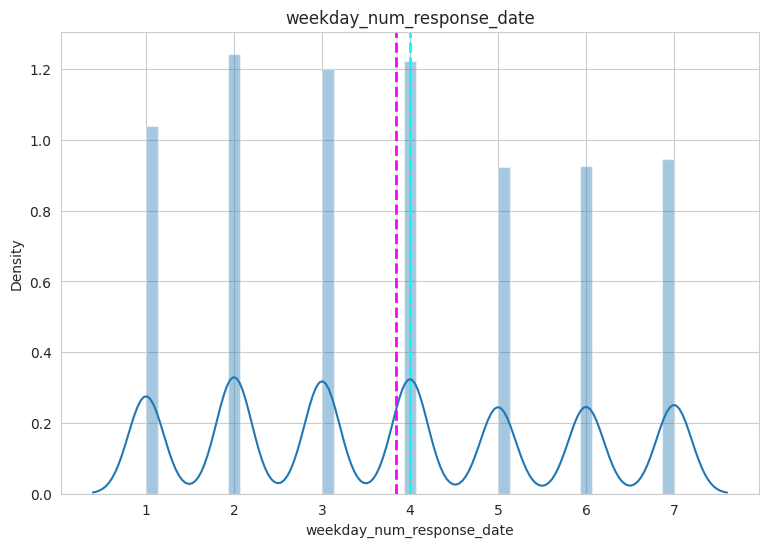

In [59]:
# Visualizing code of hist plot for each columns to know the data distibution
for col in df_removed.loc[:,symmetric_feature]:
  fig=plt.figure(figsize=(9,6))
  ax=fig.gca()
  feature= (df_removed[col])
  sns.distplot(df_removed[col])
  ax.axvline(feature.mean(),color='magenta', linestyle='dashed', linewidth=2)
  ax.axvline(feature.median(),color='cyan', linestyle='dashed', linewidth=2)
  ax.set_title(col)
plt.show()

### 6. Data Scaling


In [60]:
# Checking the data
df_removed.head()

,Item_price,connected_handling_time,CSAT Score,Agent_name_Aaron Edwards,Agent_name_Aaron Romero,Agent_name_Abigail Gonzalez,Agent_name_Adam Barnett,Agent_name_Adam Hammond,Agent_name_Adam Henderson,Agent_name_Adam Hernandez,...,Customer_City_Yeola,Customer_City_ZAHEERABAD,Customer_City_ZAMANIA,Customer_City_ZIRA,Customer_City_ZIRAKPUR,Customer_City_ZUARINAGAR,Response_Time_seconds,day_number_order_date,day_number_response_date,weekday_num_response_date
0,2.365091,462.400826,5,False,False,False,False,False,False,False,...,False,False,False,False,False,False,2.592410,1.732051,1.0,2
1,2.365091,462.400826,5,False,False,False,False,False,False,False,...,False,False,False,False,False,False,1.819272,1.732051,1.0,2
2,2.365091,462.400826,5,False,False,False,False,False,False,False,...,False,False,False,False,False,False,2.455114,1.732051,1.0,2
3,2.365091,462.400826,5,False,False,False,False,False,False,False,...,False,False,False,False,False,False,2.426038,1.732051,1.0,2
4,2.365091,462.400826,5,False,False,False,False,False,False,False,...,False,False,False,False,False,False,1.819272,1.732051,1.0,2


In [61]:
# Creating a final Copy
final_df=df_removed.copy()

In [62]:
#Dropping the target variable for Y
y=df_removed['CSAT Score']
df_removed.drop(columns=['CSAT Score'],inplace=True)

In [63]:
# Select only the numerical columns from df_removed
numerical_columns = df_removed.select_dtypes(include=['number']).columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply the scaler to the numerical columns
df_removed[numerical_columns] = scaler.fit_transform(df_removed[numerical_columns])

# Display the scaled DataFrame
df_removed.head()

,Item_price,connected_handling_time,Agent_name_Aaron Edwards,Agent_name_Aaron Romero,Agent_name_Abigail Gonzalez,Agent_name_Adam Barnett,Agent_name_Adam Hammond,Agent_name_Adam Henderson,Agent_name_Adam Hernandez,Agent_name_Adam Schwartz,...,Customer_City_Yeola,Customer_City_ZAHEERABAD,Customer_City_ZAMANIA,Customer_City_ZIRA,Customer_City_ZIRAKPUR,Customer_City_ZUARINAGAR,Response_Time_seconds,day_number_order_date,day_number_response_date,weekday_num_response_date
0,-0.09226,0.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,0.363236,-0.106597,-2.735145,-0.94492
1,-0.09226,0.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,-0.590667,-0.106597,-2.735145,-0.94492
2,-0.09226,0.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,0.193840,-0.106597,-2.735145,-0.94492
3,-0.09226,0.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,0.157965,-0.106597,-2.735145,-0.94492
4,-0.09226,0.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,-0.590667,-0.106597,-2.735145,-0.94492


In [64]:
numerical_columns

Index(['Item_price', 'connected_handling_time', 'Response_Time_seconds',
       'day_number_order_date', 'day_number_response_date',
       'weekday_num_response_date'],
      dtype='object')

### *7*. Data Splitting


In [65]:
# Extract the target variable
y = final_df['CSAT Score'].values.reshape(-1, 1)

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the target variable
y_one_hot = encoder.fit_transform(y)

# Convert to pandas DataFrame
y_one_hot_df = pd.DataFrame(y_one_hot, columns=[f'class_{int(i)}' for i in range(y_one_hot.shape[1])])

In [66]:
# Split your data to train and test. Choose Splitting ratio wisely.
 # split into 70:30 ratio

X_train, X_test, y_train, y_test = train_test_split(df_removed,y_one_hot_df, test_size = 0.3, random_state = 0)

# describes info about train and test set
print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions y_train dataset: ", y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions y_test dataset: ", y_test.shape)

Number transactions X_train dataset:  (60134, 3296)
Number transactions y_train dataset:  (60134, 5)
Number transactions X_test dataset:  (25773, 3296)
Number transactions y_test dataset:  (25773, 5)


### 8. Handling Imbalanced Dataset


class_0  class_1  class_2  class_3  class_4
0.0      0.0      0.0      0.0      1.0        41806
1.0      0.0      0.0      0.0      0.0         7840
0.0      0.0      0.0      1.0      0.0         7810
                  1.0      0.0      0.0         1801
         1.0      0.0      0.0      0.0          877
Name: count, dtype: int64
 


<Axes: ylabel='count'>

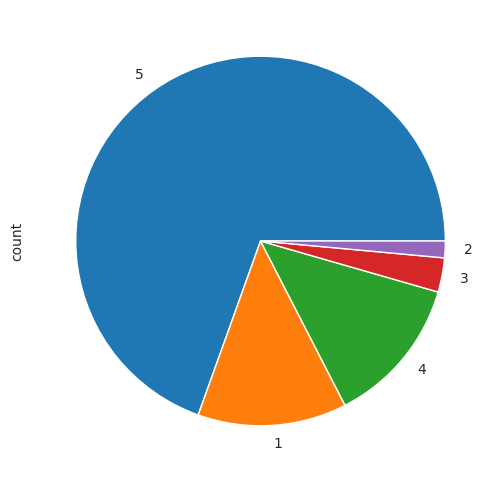

In [67]:
# Chart - 1 visualization code
# Dependant Column Value Counts
print(y_train.value_counts())
print(" ")
# Dependant Variable Column Visualization
y_train.value_counts().plot(kind='pie',
                              figsize=(15,6),
                               labels=['5','1','4','3','2'])

Imbalanced dataset is relevant primarily in the context of supervised machine learning involving two or more classes.

Imbalance means that the number of data points available for different the classes is different: If there are two classes, then balanced data would mean 50% points for each of the class. For most machine learning techniques, little imbalance is not a problem. So, if there are 60% points for one class and 40% for the other class, it should not cause any significant performance degradation. Only when the class imbalance is high, e.g. 90% points for one class and 10% for the other, standard optimization criteria or performance measures may not be as effective and would need modification.

In our case the dataset dependent column data ratio is 85:15. So, during model creating it's obvios that there will be bias and having a great chance of predicting the majority one so frequently. SO the dataset should be balanced before it going for the model creation part.

In [68]:
# Convert features to float32 (reduces memory usage)
X_train = X_train.astype('float32')

# Convert one-hot encoded labels back to a single column
if isinstance(y_train, pd.DataFrame):
    y_series = y_train.idxmax(axis=1).apply(lambda x: int(x.split('_')[1]))  # Extract numeric labels
else:
    y_series = y_train


# Get the count for each class before SMOTE
class_counts = y_series.value_counts()
majority_count = class_counts.max()
print("Majority class count:", majority_count)

# Create a sampling strategy that balances all classes to the majority count
smote_strategy = {cls: majority_count for cls in class_counts.index if cls != class_counts.idxmax()}

print("SMOTE strategy for balancing:", smote_strategy)

# Apply SMOTE with the balancing strategy
sm = SMOTE(sampling_strategy=smote_strategy, random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_series)



# Print dataset info
print("\nFinal Dataset Sizes:")
print("X_train:", X_train_resampled.shape)
print("y_train:", y_train_resampled.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Majority class count: 41806
SMOTE strategy for balancing: {0: 41806, 3: 41806, 2: 41806, 1: 41806}

Final Dataset Sizes:
X_train: (209030, 3296)
y_train: (209030,)
X_test: (25773, 3296)
y_test: (25773, 5)


In [69]:
# Print count of each class in the resampled training data
class_counts_resampled = pd.Series(y_train_resampled).value_counts()
print("Class counts after SMOTE:")
print(class_counts_resampled)


Class counts after SMOTE:
4    41806
2    41806
3    41806
0    41806
1    41806
Name: count, dtype: int64


In [70]:
#Converting the target variable train data shape that of test data shape

# Extract the target variable
y = y_train_resampled.values.reshape(-1, 1)

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the target variable
y_one_hot = encoder.fit_transform(y)

# Convert y_train_resampled_one_hot back to DataFrame for consistency
y_train_resampled_df = pd.DataFrame(y_one_hot, columns=[f'class_{int(i)}' for i in range(y_one_hot.shape[1])])

class_0  class_1  class_2  class_3  class_4
0.0      0.0      0.0      0.0      1.0        41806
                           1.0      0.0        41806
                  1.0      0.0      0.0        41806
         1.0      0.0      0.0      0.0        41806
1.0      0.0      0.0      0.0      0.0        41806
Name: count, dtype: int64
 


<Axes: ylabel='count'>

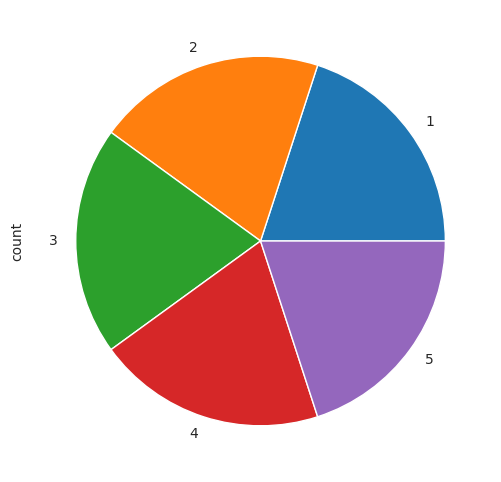

In [71]:
# Chart - 1 visualization code
# Dependant Column Value Counts
print(y_train_resampled_df.value_counts())
print(" ")
# Dependant Variable Column Visualization
y_train_resampled_df.value_counts().plot(kind='pie',
                              figsize=(15,6),
                               labels=['1','2','3','4','5']


                              )

I have used SMOTE (Synthetic Minority Over-sampling technique) for balanced the 85:15 dataset.

SMOTE is a technique in machine learning for dealing with issues that arise when working with an unbalanced data set. In practice, unbalanced data sets are common and most ML algorithms are highly prone to unbalanced data so we need to improve their performance by using techniques like SMOTE.

To address this disparity, balancing schemes that augment the data to make it more balanced before training the classifier were proposed. Oversampling the minority class by duplicating minority samples or undersampling the majority class is the simplest balancing method.

The idea of incorporating synthetic minority samples into tabular data was first proposed in SMOTE, where synthetic minority samples are generated by interpolating pairs of original minority points.

SMOTE is a data augmentation algorithm that creates synthetic data points from raw data. SMOTE can be thought of as a more sophisticated version of oversampling or a specific data augmentation algorithm.

SMOTE has the advantage of not creating duplicate data points, but rather synthetic data points that differ slightly from the original data points. SMOTE is a superior oversampling option.

That's why for lots of advantages, I have used SMOTE technique for balancinmg the dataset.

In [72]:
# Describe info about train and test set
print("Number of transactions in X_train dataset: ", X_train_resampled.shape)
print("Number of transactions in y_train dataset: ", y_train_resampled_df.shape)
print("Number of transactions in X_test dataset: ", X_test.shape)
print("Number of transactions in y_test dataset: ", y_test.shape)

Number of transactions in X_train dataset:  (209030, 3296)
Number of transactions in y_train dataset:  (209030, 5)
Number of transactions in X_test dataset:  (25773, 3296)
Number of transactions in y_test dataset:  (25773, 5)


## ***7. ML Model Implementation***

## Ensuring the target labels in the correct format.


In [73]:
# Ensure target labels are numerical and feature arrays are float
y_train_numerical = y_train_resampled_df.astype(int)
y_test_numerical = y_test.astype(int)

# Convert DataFrame to numpy array and ensure float32 type
X_train_array = X_train_resampled.values.astype(np.float32)
X_test_array = X_test.values.astype(np.float32)

# Ensure target labels are numpy arrays
y_train_array = np.array(y_train_numerical)
y_test_array = np.array(y_test_numerical)

In [74]:
# Get input dimensions
input_dim = X_train.shape[1]
num_classes = len(np.unique(y))
input_dim ,num_classes

(3296, 5)

## Define the ANN Model

In [75]:
# Defining the learning scheduler

def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

In [76]:
# Dropout rate
dropout_rate = 0.5

# Define the neural network model with BatchNormalization and Dropout layers
neural_classifier = Sequential(
    [
        Dense(128, activation="relu", kernel_regularizer=l2(),input_dim=X_train.shape[1]),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(96, activation="relu", kernel_regularizer=l2()),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(64, activation="relu", kernel_regularizer=l2()),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(32, activation="relu", kernel_regularizer=l2()),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(num_classes, activation="softmax")
    ]
)

# Print the model summary
neural_classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       422,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 444,133 (1.69 MB)

 Trainable params: 443,493 (1.69 MB)

 Non-trainable params: 640 (2.50 KB)

## Define and Initialize the Keras Classifier model

In [77]:
### Initialize Model

scikeras_classifier = KerasClassifier(model=neural_classifier,
                                    optimizer="adam",
                                    loss=keras.losses.categorical_crossentropy,
                                    batch_size=4000,
                                    epochs=30,
                                    metrics=['accuracy'],
                                    random_state=42,
                                    warm_start=True
                          )

##  Initialize StratifiedKFold Cross Validation (no. of folds=3)

In [78]:
# Define number of folds
n_folds = 3

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)


## Performing 3-fold cross validation and training the ANN deep learning model

In [ ]:
# Lists to store train and test accuracies
train_accuracies = []
test_accuracies = []

# Lists to store train and test accuracies for visualization
history_list = []

# Perform 3-fold cross-validation
for train_index, test_index in skf.split(X_train_array, np.argmax(y_train_array, axis=1)):
    X_train_fold, X_test_fold = X_train_array[train_index], X_train_array[test_index]
    y_train_fold, y_test_fold = y_train_array[train_index], y_train_array[test_index]

    # Define EarlyStopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    # Define LearningRateScheduler callback
    lr_scheduler = LearningRateScheduler(scheduler)

    # Fit the model with early stopping and learning rate scheduler
    scikeras_classifier.fit(X_train_fold, y_train_fold,
              validation_data=(X_test_fold, y_test_fold),
              callbacks=[early_stopping, lr_scheduler],
              verbose=1)

    # Append the history for visualization later
    history_list.append(scikeras_classifier.history_)

    # Evaluate the model on train data
    train_accuracy = scikeras_classifier.score(X_train_fold, y_train_fold)
    train_accuracies.append(train_accuracy)

    # Evaluate the model on test data
    test_accuracy = scikeras_classifier.score(X_test_fold, y_test_fold)
    test_accuracies.append(test_accuracy)

    # Train metric
    y_pred_tr = scikeras_classifier.predict(X_train_fold)
    y_pred_classes_tr = np.argmax(y_pred_tr, axis=1)
    y_test_classes_tr = np.argmax(y_train_fold, axis=1)

    # Test Metric
    y_pred = scikeras_classifier.predict(X_test_fold)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test_fold, axis=1)

    print("Train Accuracy:", accuracy_score(y_test_classes_tr, y_pred_classes_tr))
    print("Test Accuracy:", accuracy_score(y_test_classes, y_pred_classes))
    print("Classification Report:\n", classification_report(y_test_classes, y_pred_classes))

## Evaluating performance of ANN deep learning model


In [ ]:
# Calculate mean train and test accuracies
mean_train_accuracy = np.mean(train_accuracies)
mean_test_accuracy = np.mean(test_accuracies)

# Evaluation Metrics
print("Mean Train Accuracy:", mean_train_accuracy)
print("Mean Test Accuracy:", mean_test_accuracy)

In [ ]:
# Compute mean scores across 3 folds
mean_train_acc = np.mean(train_accuracies)
mean_test_acc = np.mean(test_accuracies)

# Print overall metrics
print("\nFinal Metrics After 3-Fold Cross-Validation:")
print(f"Mean Train Accuracy: {mean_train_acc:.4f}")
print(f"Mean Test Accuracy: {mean_test_acc:.4f}")

# Compute precision, recall, and F1-score for each class on test set
precision, recall, f1, _ = precision_recall_fscore_support(y_test_classes, y_pred_classes, average=None)

# Print per-class metrics
print("\nPer-Class Metrics:")
for i in range(len(precision)):
    print(f"Class {i}: Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1-score: {f1[i]:.4f}")

# Compute and plot ROC-AUC curve (One-vs-Rest for multi-class)
y_test_bin = label_binarize(y_test_classes, classes=np.unique(y_test_classes))
y_pred_bin = label_binarize(y_pred_classes, classes=np.unique(y_test_classes))

n_classes = y_test_bin.shape[1]
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve (After 3 Folds)")
plt.legend()
plt.show()


### **Model Evaluation & Interpretation**  
The trained Artificial Neural Network (ANN) model demonstrates strong predictive capabilities, achieving a **mean train accuracy of 77.9%** and a **mean test accuracy of 75.01%**, indicating good generalization across datasets.  

From the per-class evaluation, we observe that **Classes 1 and 2** are well-classified, with **AUC scores of 1.00 and 0.99**, respectively, reflecting near-perfect separability. **Class 0** also performs well with an **AUC of 0.87**, showing strong predictive power. However, **Class 3 and Class 4 exhibit lower performance**, with **AUC scores of 0.82 and 0.67**, respectively. This suggests potential challenges in distinguishing these categories, likely due to class imbalance or feature overlap.  

While the model performs effectively overall, improvements can be made by **enhancing feature selection, applying class balancing techniques like SMOTE, or fine-tuning hyperparameters** to improve the classification of underperforming classes. Despite these limitations, the model provides **valuable insights into customer satisfaction prediction**, supporting data-driven decision-making for improving e-commerce service quality.

## Conclusion

1. **Problem Statement:** The project aimed to predict Customer Satisfaction (CSAT) scores for Shopzilla using deep learning techniques, specifically Artificial Neural Networks (ANNs).  
2. **Dataset Overview:** The dataset consisted of customer interaction data, including multiple features that influence customer satisfaction levels.  
3. **Data Preprocessing:** Applied feature engineering, handled missing values, normalized numerical features, and transformed categorical variables to prepare data for ANN training.  
4. **Model Selection:** Chose an ANN-based classification model to capture complex patterns in customer behavior and satisfaction levels.  
5. **Cross-Validation:** Implemented 3-fold cross-validation to ensure model robustness and prevent overfitting.  
6. **Model Performance:** Achieved a mean training accuracy of **77.9%** and a mean test accuracy of **75.01%**, indicating a well-generalized model.  
7. **Per-Class Performance:**  
   - **High performance for Class 1 (AUC = 1.00) and Class 2 (AUC = 0.99)** indicates strong model capability in identifying these satisfaction levels.  
   - **Moderate performance for Class 3 (AUC = 0.82) and Class 0 (AUC = 0.87)** suggests room for improvement in distinguishing these cases.  
   - **Lower performance for Class 4 (AUC = 0.67)** highlights a challenge in predicting this category, requiring further feature engineering or data balancing.  
8. **Evaluation Metrics:** Assessed the model using precision, recall, F1-score, and ROC-AUC curves, ensuring a balanced evaluation across different satisfaction levels.  
9. **Insights:** Identified key factors influencing customer satisfaction, enabling businesses to take data-driven actions for improving service quality.   
11. **Business Impact:** The model provides actionable insights that can help Shopzilla improve customer retention, optimize service offerings, and enhance overall user experience.  
12. **Final Takeaway:** The ANN model successfully predicts customer satisfaction scores, demonstrating the effectiveness of deep learning in customer sentiment analysis and business decision-making.  
